# Exemplo 06 - Visão computacional: reconhecendo imagens com uma CNN

### Palestra Machine Learning e IA: Da máquina que aprende à IA que age

### Prof. Dr. Ahirton Lopes (https://github.com/ahirtonlopes)

**Onde isso aparece no mercado:** Sistemas de assistência ao motorista, inspeção de qualidade em fábricas e apps de fotos usam redes convolucionais para reconhecer carros, pessoas, defeitos e objetos em imagens.

**Conceito da palestra:** Redes neurais convolucionais aprendem sozinhas os padrões visuais (bordas, texturas, formas) direto dos pixels.

### Carregando a base CIFAR-10 (imagens rotuladas em macro categorias)

*** Mais informações em https://www.cs.toronto.edu/~kriz/cifar.html ***

In [1]:
import keras
from keras.datasets import cifar10

# carregando o dataset pré-randomizado de treinamento bem como os dados de teste

(x_train, y_train), (x_test, y_test) = cifar10.load_data()

## Visualizando as primeiras 36 imagens do dataset de treinamento

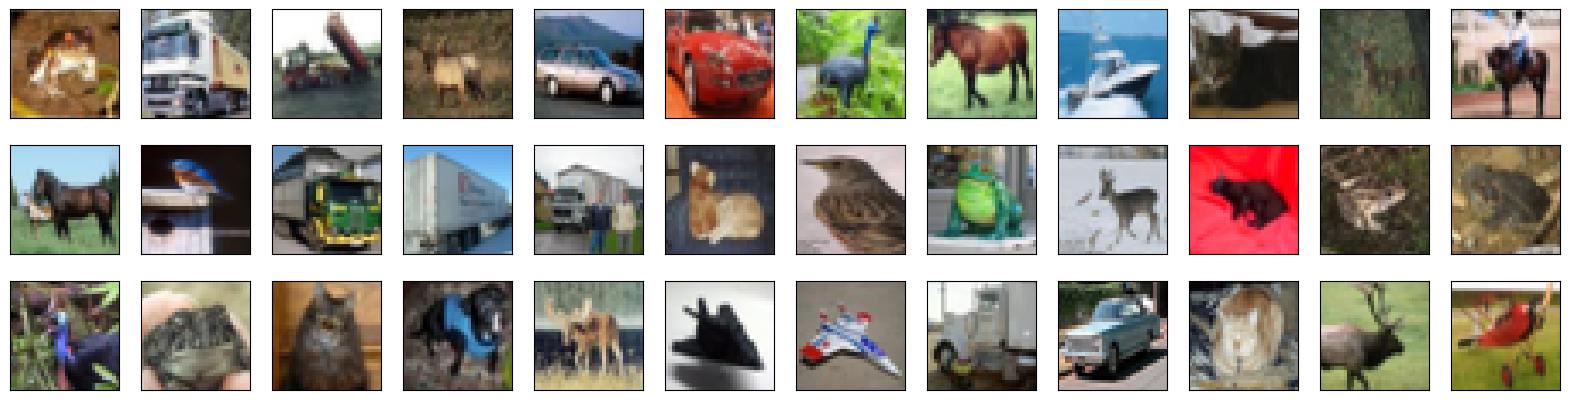

In [2]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

fig = plt.figure(figsize=(20,5))
for i in range(36):
    ax = fig.add_subplot(3, 12, i + 1, xticks=[], yticks=[])
    ax.imshow(np.squeeze(x_train[i]))


## Redimensionando as imagens e dividindo cada pixel em cada imagem por 255

In [3]:
# redimensionamento [0,255] --> [0,1]

x_train = x_train.astype('float32')/255
x_test = x_test.astype('float32')/255

### Por que normalizar os dados?

Redimensionamos os valores dos pixels de 0-255 para 0-1. Este processo, conhecido como **normalização**, é crucial por duas razões principais:

1.  **Melhora o desempenho do treinamento**: Muitos algoritmos de aprendizado de máquina e redes neurais se beneficiam quando os dados de entrada estão em uma escala menor e consistente. Valores menores impedem que gradientes explodam ou desapareçam durante o treinamento.
2.  **Acelera a convergência**: Redes neurais geralmente convergem mais rapidamente para uma solução ótima quando as características de entrada são normalizadas.

## Dividindo o dataset em treinamento, teste e validação

In [4]:
from keras.utils import to_categorical

# "one-hot encoding" aplicado aos rótulos

num_classes = len(np.unique(y_train))
y_train = keras.utils.to_categorical(y_train, num_classes)
y_test = keras.utils.to_categorical(y_test, num_classes)

# divindo dataset de treinamento em treinamento, teste e validação

(x_train, x_valid) = x_train[5000:], x_train[:5000]
(y_train, y_valid) = y_train[5000:], y_train[:5000]

# impressão da forma do conjunto de treino

print('formato x_train:', x_train.shape)

# impressão do número de imagens nos datasets de treinamento, teste e validação

print(x_train.shape[0], 'amostras de treinamento')
print(x_test.shape[0], 'amostras de teste')
print(x_valid.shape[0], 'amostras de validação')

formato x_train: (45000, 32, 32, 3)
45000 amostras de treinamento
10000 amostras de teste
5000 amostras de validação


### Por que 'One-Hot Encoding'?

A aplicação de 'one-hot encoding' aos rótulos das classes (`y_train`, `y_test`, `y_valid`) transforma os rótulos inteiros (por exemplo, 0, 1, 2...) em vetores binários. Por exemplo, se temos 10 classes, um rótulo '3' se tornaria `[0, 0, 0, 1, 0, 0, 0, 0, 0, 0]`.

Isso é importante para problemas de classificação multi-classe com redes neurais, especialmente quando usamos a função de perda `categorical_crossentropy`, porque:

1.  **Representação Categórica**: As redes neurais tratam as categorias como valores discretos e independentes, não como números ordinais (onde '2' é maior que '1').
2.  **Cálculo de Perda**: A 'categorical_crossentropy' espera essa formato para comparar a saída da rede (probabilidades) com a verdadeira distribuição de probabilidade da classe.

## Definindo a arquitetura do modelo (IMPORTANTE!)

* 3 camadas convolucionais de tamanho progressivamente crescente
* Máximo de camadas de "pooling" (2x2) seguidas por tais 3 camadas convolucionais
* Uma camada do tipo totalmente conectada de 100 neurônios
* Últimas camadas do tipo totalmente conectadas de 10 saídas (10 classes de categoria de imagem)
* "Dropout" de 0,2-0,3

In [5]:
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

model = Sequential()
model.add(keras.Input(shape=(32, 32, 3)))  # formato de cada imagem: 32x32 pixels, 3 canais (RGB)
model.add(Conv2D(filters=32, kernel_size=2, padding='same', activation='relu'))
model.add(MaxPooling2D(pool_size=2))
model.add(Conv2D(filters=64, kernel_size=2, padding='same', activation='relu'))
model.add(MaxPooling2D(pool_size=2))
model.add(Conv2D(filters=128, kernel_size=2, padding='same', activation='relu'))
model.add(MaxPooling2D(pool_size=2))
model.add(Dropout(0.3))
model.add(Flatten())
model.add(Dense(100, activation='relu'))
model.add(Dropout(0.4))
model.add(Dense(10, activation='softmax'))

# tentem com outras funções de ativação!
# mais informações em https://keras.io/activations/

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 100)            │       204,900 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 247,478 (966.71 KB)

 Trainable params: 247,478 (966.71 KB)

 Non-trainable params: 0 (0.00 B)

### Entendendo o 'Model Summary'

O `model.summary()` nos dá uma visão geral da arquitetura da rede neural. Vamos analisar as colunas:

*   **Layer (type)**: O nome e o tipo de cada camada na rede (por exemplo, `Conv2D`, `MaxPooling2D`, `Dense`).
*   **Output Shape**: A forma (dimensão) da saída de cada camada. Isso é crucial para entender como os dados se transformam ao longo da rede. Por exemplo, as camadas `MaxPooling2D` reduzem a dimensão espacial.
*   **Param #**: O número de parâmetros treináveis (pesos e vieses) em cada camada. A soma total desses parâmetros é o que a rede precisa aprender durante o treinamento.
    *   Para camadas `Conv2D`, o número de parâmetros é calculado como `(kernel_size_w * kernel_size_h * input_channels + 1) * filters`.
    *   Para camadas `Dense`, é `(input_units + 1) * output_units`.

## Compilando o modelo

In [6]:
# compilando o modelo escolhendo como se dará nossa perda, otimização e métricas (parâmetros do Keras)
# mais informações em https://keras.io/losses/
# mais informações em https://keras.io/optimizers/
# mais informações em https://keras.io/metrics/

model.compile(loss='categorical_crossentropy', optimizer='rmsprop',
                  metrics=['accuracy'])

## Treinando o modelo

In [7]:
from keras.callbacks import ModelCheckpoint

# 5 épocas rodam em poucos minutos no Colab (bem mais rápido com GPU T4).
# Quer uma acurácia maior? Aumente para 10 ou 20 e compare.
EPOCHS = 5

checkpointer = ModelCheckpoint(filepath='model.weights.best.keras', verbose=1,
                               save_best_only=True)
hist = model.fit(x_train, y_train, batch_size=64, epochs=EPOCHS,
          validation_data=(x_valid, y_valid), callbacks=[checkpointer],
          verbose=2, shuffle=True)

# tentem mudar o número de épocas de treinamento e verificar o comportamento de nosso algoritmo

Epoch 1/5



Epoch 1: val_loss improved from None to 1.63326, saving model to model.weights.best.keras



Epoch 1: finished saving model to model.weights.best.keras


704/704 - 4s - 5ms/step - accuracy: 0.3574 - loss: 1.7537 - val_accuracy: 0.4162 - val_loss: 1.6333


Epoch 2/5


...

704/704 - 3s - 5ms/step - accuracy: 0.6013 - loss: 1.1277 - val_accuracy: 0.6186 - val_loss: 1.0973


Epoch 5/5



Epoch 5: val_loss improved from 1.08301 to 1.06025, saving model to model.weights.best.keras



Epoch 5: finished saving model to model.weights.best.keras


704/704 - 4s - 5ms/step - accuracy: 0.6277 - loss: 1.0532 - val_accuracy: 0.6292 - val_loss: 1.0603


### Analisando o Processo de Treinamento

Durante o treinamento do modelo (`model.fit`), observamos as seguintes métricas a cada época:

*   **`loss`**: A função de perda no conjunto de treinamento. Indica o quão bem o modelo está aprendendo com os dados que já viu. Um valor menor é melhor.
*   **`accuracy`**: A precisão no conjunto de treinamento. Representa a proporção de classificações corretas nos dados de treinamento. Um valor maior é melhor.
*   **`val_loss`**: A função de perda no conjunto de validação. Esta é a métrica mais importante para avaliar o desempenho real do modelo em dados **não vistos**. Um aumento na `val_loss` enquanto a `loss` continua diminuindo pode indicar **overfitting**.
*   **`val_accuracy`**: A precisão no conjunto de validação. Assim como a `val_loss`, indica o desempenho do modelo em dados não vistos. Queremos que a `val_accuracy` seja alta e próxima da `accuracy` de treinamento.

O `ModelCheckpoint` salva o modelo (`model.weights.best.keras`) apenas quando a `val_loss` melhora, garantindo que tenhamos os pesos do modelo que tiveram o melhor desempenho no conjunto de validação.

## Carregando o modelo com a melhor precisão de validação

In [8]:
# carregando os pesos que geraram a melhor precisão de validação

model.load_weights('model.weights.best.keras')

## Cálculo da precisão de classificação no dataset de testes

In [9]:
# avaliando e imprimindo a precisão do teste

score = model.evaluate(x_test, y_test, verbose=0)
print('\n', ' Acuracia de Teste:', score[1])


  Acuracia de Teste: 0.6223000288009644


## Visualizar algumas predições

As visualizações podem nos dar algumas dicas sobre por que a rede classifica erroneamente alguns objetos.

In [10]:
# obtendo previsões no conjunto de testes

y_hat = model.predict(x_test)

# definindo rótulos de texto (rótulos disponíveis na fonte original: https://www.cs.toronto.edu/~kriz/cifar.html)

cifar10_labels = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


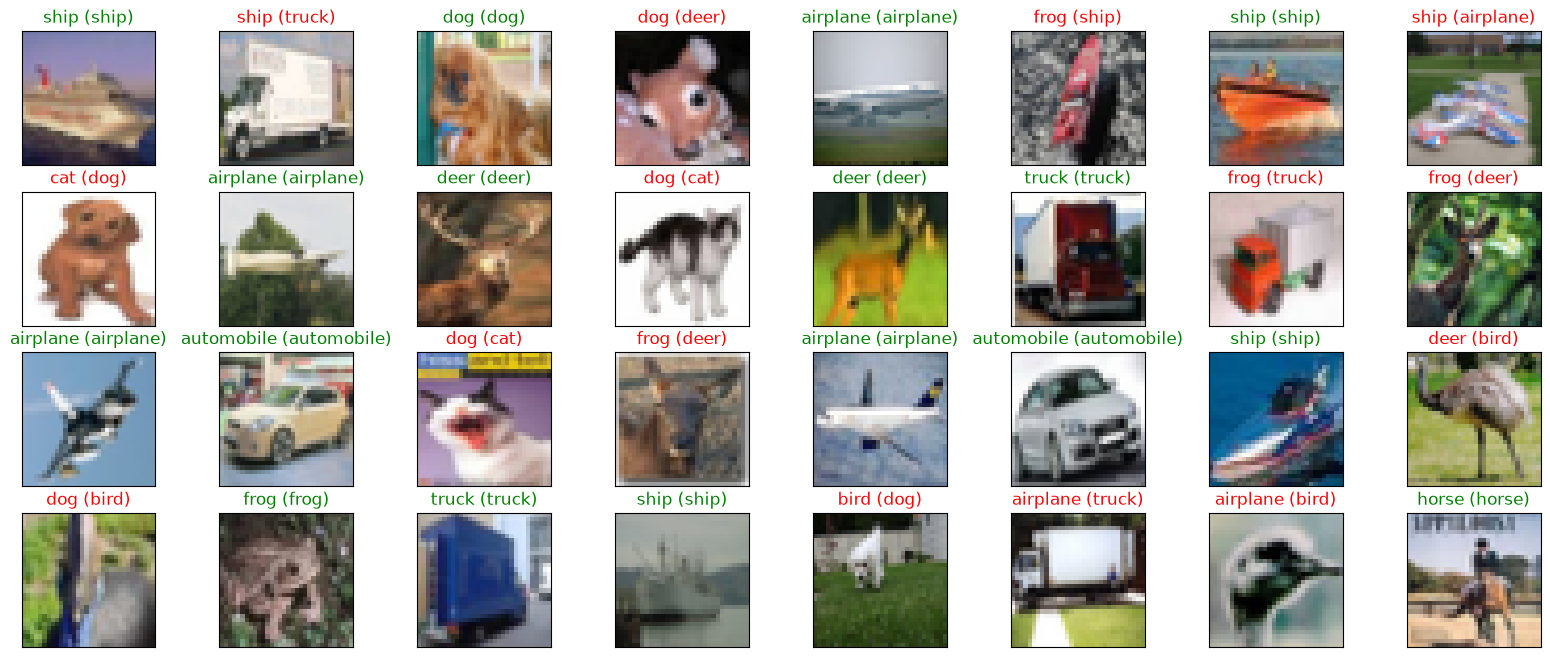

In [11]:
# plot de amostra aleatória de imagens de teste, rótulos preditos e a "ground truth" advinda do dataset CIFAR-10

fig = plt.figure(figsize=(20, 8))
for i, idx in enumerate(np.random.choice(x_test.shape[0], size=32, replace=False)):
    ax = fig.add_subplot(4, 8, i + 1, xticks=[], yticks=[])
    ax.imshow(np.squeeze(x_test[idx]))
    pred_idx = np.argmax(y_hat[idx])
    true_idx = np.argmax(y_test[idx])
    ax.set_title("{} ({})".format(cifar10_labels[pred_idx], cifar10_labels[true_idx]),
                 color=("green" if pred_idx == true_idx else "red"))

    # amostras corretamente classificadas em verde e incorretamente classificadas em vermelho
